In [ ]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = '46_Col_final_with_county.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows


print(f"Total Rows: {total_rows}")
print("Columns to remove (>50% null):", high_null_cols)

Total Rows: 1351582
Columns to remove (>50% null): []


In [5]:
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])

PredominantRoofType          141260
PercentageDraughtStripped     24127
NoOfSidesSheltered            24127
SuspendedWoodenFloor          24127
StructureType                 24127
VentilationMethod             24127
NoOfFansAndVents              24127
WHRenewableResources          23467
SupplWHFuel                   23467
SupplSHFuel                   23467
WHEffAdjFactor                23467
WHMainSystemEff               23467
HSSupplSystemEff              23467
HSSupplHeatFraction           23467
HSEffAdjFactor                23467
SHRenewableResources          23467
HSMainSystemEfficiency        23467
dtype: int64


In [10]:
import pandas as pd

# Path to your file
input_file = '46_Col_final_with_county.parquet'

# 1. Identify the groups of columns with the same NULL count
# (Assuming you already have 'null_counts' from your previous step)
counts_series = null_counts[null_counts > 0]
duplicates = counts_series[counts_series.duplicated(keep=False)]
groups = duplicates.groupby(duplicates.values).groups

# 2. Initialize counters to track overlaps
# This will count how many rows are null for ALL columns in a group
overlap_trackers = {count: 0 for count in groups.keys()}

print(f"Processing in chunks to check overlap for {len(groups)} groups...")

# 3. Iterate through the file in chunks
chunk_size = 100000
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    for count_val, cols in groups.items():
        # For this chunk, count rows where EVERY column in the group is null
        is_fully_null = chunk[list(cols)].isnull().all(axis=1)
        overlap_trackers[count_val] += is_fully_null.sum()

# 4. Print the final analysis
print("\n" + "="*50)
print("NULL ROW OVERLAP ANALYSIS")
print("="*50)

for count_val, cols in groups.items():
    actual_overlap = overlap_trackers[count_val]
    
    print(f"\nGroup Shared Count: {count_val}")
    print(f"Columns: {list(cols)}")
    
    if actual_overlap == count_val:
        print(f"✅ SUCCESS: These columns are missing data in the EXACT SAME {count_val} rows.")
        print("   (Conclusion: These columns belong to a specific survey block that was skipped.)")
    else:
        print(f"❌ PARTIAL OVERLAP: Only {actual_overlap} rows overlap out of {count_val}.")
        print("   (Conclusion: The missing values are scattered across different rows.)")

print("\n" + "="*50)


Processing in chunks to check overlap for 2 groups...

NULL ROW OVERLAP ANALYSIS

Group Shared Count: 23467
Columns: ['HSMainSystemEfficiency', 'HSEffAdjFactor', 'HSSupplHeatFraction', 'HSSupplSystemEff', 'WHMainSystemEff', 'WHEffAdjFactor', 'SupplSHFuel', 'SupplWHFuel', 'SHRenewableResources', 'WHRenewableResources']
✅ SUCCESS: These columns are missing data in the EXACT SAME 23467 rows.
   (Conclusion: These columns belong to a specific survey block that was skipped.)

Group Shared Count: 24127
Columns: ['NoOfFansAndVents', 'VentilationMethod', 'StructureType', 'SuspendedWoodenFloor', 'PercentageDraughtStripped', 'NoOfSidesSheltered']
✅ SUCCESS: These columns are missing data in the EXACT SAME 24127 rows.
   (Conclusion: These columns belong to a specific survey block that was skipped.)



In [11]:
import pandas as pd
import numpy as np

# Load just the columns needed for grouping to save memory
group_cols = ['Year_of_Construction', 'DwellingTypeDescr', 'CountyName']
envelope_cols = [
    'NoOfFansAndVents', 'VentilationMethod', 'StructureType', 
    'SuspendedWoodenFloor', 'PercentageDraughtStripped', 'NoOfSidesSheltered'
]

# Create a master lookup table
lookups = {}

# Scan the dataset (or a large representative sample) to find global modes
# If the file is too big, use a 10-20% random sample to determine the modes
sample_df = pd.read_parquet('46_Col_final_with_county.parquet', columns=group_cols + envelope_cols)

for col in envelope_cols:
    # Build a lookup: (Year, Type, County) -> Mode
    lookup = sample_df.groupby(group_cols)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    lookups[col] = lookup.to_dict()

del sample_df # Free up memory

/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/2531631931.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lookup = sample_df.groupby(group_cols)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/2531631931.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  lookup = sample_df.groupby(group_cols)[col].agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_14959/2531631931.py:20: FutureWarning: The default of observed=False is deprecated and wi

In [ ]:
# # 1️⃣ Compute global medians once (outside the chunk‑processing loop)
# global_medians = {}
# for col in eff_cols:
#     # Read the whole column (or a representative sample) to get its median
#     global_medians[col] = pd.read_parquet(
#         '46_Col_final_with_county.parquet',
#         columns=[col]
#     )[col].median()

# # 2️⃣ Inside the chunk‑processing loop, use the pre‑computed value
# for col in eff_cols:
#     if col in chunk.columns:
#         # Use the global median instead of the chunk median
#         chunk[col] = chunk[col].fillna(global_medians[col])


NameError: name 'eff_cols' is not defined

In [ ]:
# this is basic mean,mode,0 fillinf process now trying differe 
def process_chunk(chunk, lookups):
    # --- 1. PRIORITY BLOCK: Logical Zero-Fill ---
    # These MUST be 0 if missing, as they indicate absence of systems
    zero_cols = [
        'HSSupplHeatFraction', 'SHRenewableResources', 'WHRenewableResources', 
        'HSSupplSystemEff', 'WHEffAdjFactor', 'SupplSHFuel', 'SupplWHFuel'
    ]
    for col in zero_cols:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna(0)

    # --- 2. CONTEXTUAL BLOCK: Mode Mapping ---
    # These depend on building era and location
    for col, mapping in lookups.items():
        if col in chunk.columns:
            # Create the key for the lookup
            keys = list(zip(chunk['Year_of_Construction'], chunk['DwellingTypeDescr'], chunk['CountyName']))
            
            # Map values and ensure index alignment
            fill_series = pd.Series([mapping.get(k, np.nan) for k in keys], index=chunk.index)
            chunk[col] = chunk[col].fillna(fill_series)
            
            # Local Fallback: If group mapping failed, use the chunk's mode
            if chunk[col].isnull().any():
                m = chunk[col].mode()
                chunk[col] = chunk[col].fillna(m[0] if not m.empty else 0)

    # --- 3. EFFICIENCY BLOCK ---
    # Physical drivers that should not be zero
    eff_cols = ['HSMainSystemEfficiency', 'WHMainSystemEff']
    for col in eff_cols:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna(chunk[col].median())
    # Apply this logic within your process_chunk function
    # Priority: Logical Zero-Fill for the specific skipped block
    if 'HSEffAdjFactor' in chunk.columns:
        chunk['HSEffAdjFactor'] = chunk['HSEffAdjFactor'].fillna(0)

    # # --- 4. THE SAFETY NET: PredominantRoofType & Others ---
    # # If anything else is STILL null (like RoofType with 141k missing), fill with global mode
    # remaining_nulls = chunk.columns[chunk.isnull().any()].tolist()
    # for col in remaining_nulls:
    #     chunk[col] = chunk[col].fillna(chunk[col].mode()[0] if not chunk[col].mode().empty else 0)
    
    return chunk

In [ ]:
# !pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 686.0/686.0 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]


In [28]:
# --- Execution ---
import pyarrow.parquet as pq

parquet_file = pq.ParquetFile('46_Col_final_with_county.parquet')
output_file = 'BER_Cleaned_Final_fill_missing_values.parquet'

for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    cleaned_chunk = process_chunk(chunk, lookups)
    
    # Save or append to new file
    if i == 0:
        cleaned_chunk.to_parquet(output_file, engine='fastparquet')
    else:
        cleaned_chunk.to_parquet(output_file, engine='fastparquet', append=True)

In [34]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = 'BER_Cleaned_Final_fill_missing_values.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])



PredominantRoofType    141260
dtype: int64


In [31]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression

# Load only the columns needed for training (memory-efficient)
train_cols = ['Year_of_Construction', 'DwellingTypeDescr', 
              'StructureType', 'VentilationMethod', 
              'SuspendedWoodenFloor', 'PercentageDraughtStripped', 
              'NoOfSidesSheltered', 'NoOfFansAndVents']

df_train = pd.read_parquet('46_Col_final_with_county.parquet', columns=train_cols)

# --- Encode DwellingTypeDescr for use in regression ---
dwelling_encoder = LabelEncoder()
df_train['DwellingTypeDescr_enc'] = dwelling_encoder.fit_transform(
    df_train['DwellingTypeDescr'].astype(str)
)

# Features used to predict missing envelope values
feature_cols = ['Year_of_Construction', 'DwellingTypeDescr_enc']

# Dictionary to hold pre-trained models
envelope_cols_info = {
    # col_name: ('classification' or 'regression', model, encoder_or_None)
}

envelope_cols = {
    'StructureType': 'classification',
    'VentilationMethod': 'classification',
    'SuspendedWoodenFloor': 'classification',
    'PercentageDraughtStripped': 'regression',
    'NoOfSidesSheltered': 'regression',
    'NoOfFansAndVents': 'regression',
}

label_encoders = {}  # Store encoders for categorical columns
trained_models = {}  # Store trained models

for col, task_type in envelope_cols.items():
    print(f"Training model for: {col}...")
    
    # Use only rows where this column is NOT null (complete cases to learn from)
    mask = df_train[feature_cols + [col]].dropna()
    X = mask[feature_cols].values
    y = mask[col]
    
    if task_type == 'classification':
        # Encode the target categorical column
        le = LabelEncoder()
        y_enc = le.fit_transform(y.astype(str))
        label_encoders[col] = le
        
        model = LogisticRegression(max_iter=500, random_state=42)
        model.fit(X, y_enc)
        trained_models[col] = ('classification', model)
        
    else:  # regression
        model = LinearRegression()
        model.fit(X, y.values)
        trained_models[col] = ('regression', model)

print("\n✅ All models trained!")
del df_train  # Free memory


Training model for: StructureType...
Training model for: VentilationMethod...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training model for: SuspendedWoodenFloor...
Training model for: PercentageDraughtStripped...
Training model for: NoOfSidesSheltered...
Training model for: NoOfFansAndVents...

✅ All models trained!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression

# Load only the columns needed for training (memory-efficient) ,Removing outliers 
train_cols = ['Year_of_Construction', 'DwellingTypeDescr', 
              'StructureType', 'VentilationMethod', 
              'SuspendedWoodenFloor', 'PercentageDraughtStripped', 
              'NoOfSidesSheltered', 'NoOfFansAndVents']

df_train = pd.read_parquet('46_Col_final_with_county.parquet', columns=train_cols)

# --- Encode DwellingTypeDescr for use in regression ---
dwelling_encoder = LabelEncoder()
df_train['DwellingTypeDescr_enc'] = dwelling_encoder.fit_transform(
    df_train['DwellingTypeDescr'].astype(str)
)

# Features used to predict missing envelope values
feature_cols = ['Year_of_Construction', 'DwellingTypeDescr_enc']

envelope_cols = {
    'StructureType': 'classification',
    'VentilationMethod': 'classification',
    'SuspendedWoodenFloor': 'classification',
    'PercentageDraughtStripped': 'regression',
    'NoOfSidesSheltered': 'regression',
    'NoOfFansAndVents': 'regression',
}

label_encoders = {}  # Store encoders for categorical columns
trained_models = {}  # Store trained models

for col, task_type in envelope_cols.items():
    print(f"Training model for: {col}...")
    
    # Use only rows where this column is NOT null (complete cases to learn from)
    mask = df_train[feature_cols + [col]].dropna()
    
    # --- OUTLIER REMOVAL (IQR METHOD) FOR REGRESSION ---
    # We only apply this to regression tasks since classifications have fixed labels
    if task_type == 'regression':
        Q1 = mask[col].quantile(0.25)
        Q3 = mask[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Only filter if IQR > 0 (prevents accidentally wiping datasets heavily skewed to a single value)
        if IQR > 0:
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter the training rows removing extreme numerical outliers
            mask = mask[(mask[col] >= lower_bound) & (mask[col] <= upper_bound)]
            print(f"  -> Applied IQR filtering for {col}: kept values between {lower_bound:.2f} and {upper_bound:.2f}")

    X = mask[feature_cols].values
    y = mask[col]
    
    if task_type == 'classification':
        # Encode the target categorical column
        le = LabelEncoder()
        y_enc = le.fit_transform(y.astype(str))
        label_encoders[col] = le
        
        model = LogisticRegression(max_iter=500, random_state=42)
        model.fit(X, y_enc)
        trained_models[col] = ('classification', model)
        
    else:  # regression
        model = LinearRegression()
        model.fit(X, y.values)
        trained_models[col] = ('regression', model)

print("\n✅ All models trained (with regression outliers suppressed)!")
del df_train  # Free memory


Training model for: StructureType...
Training model for: VentilationMethod...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training model for: SuspendedWoodenFloor...
Training model for: PercentageDraughtStripped...
  -> Applied IQR filtering for PercentageDraughtStripped: kept values between 82.50 and 110.50
Training model for: NoOfSidesSheltered...
  -> Applied IQR filtering for NoOfSidesSheltered: kept values between 0.50 and 4.50
Training model for: NoOfFansAndVents...
  -> Applied IQR filtering for NoOfFansAndVents: kept values between -3.50 and 8.50

✅ All models trained (with regression outliers suppressed)!


In [2]:
def process_chunk(chunk, dwelling_encoder, trained_models, label_encoders):
    chunk = chunk.copy()
    
    # ============================================================
    # GROUP 1: Systems Block (NMAR) → Logical Zero-Fill
    # Logic: Null = "no supplemental system exists" → fill with 0
    # ============================================================
    zero_fill_num = [
        'HSSupplHeatFraction', 
        'SHRenewableResources', 
        'WHRenewableResources', 
        'HSSupplSystemEff', 
        'WHEffAdjFactor',
        'HSMainSystemEfficiency',
        'WHMainSystemEff',
    ]
    chunk[zero_fill_num] = chunk[zero_fill_num].fillna(0)
    
    # Fuel types filled with 0 (treat as "No Fuel / None category")
    chunk[['SupplSHFuel', 'SupplWHFuel']] = chunk[['SupplSHFuel', 'SupplWHFuel']].fillna(0)
    
    # ============================================================
    # GROUP 2: Building Envelope Block (MAR) → Regression Fill
    # Logic: Predict missing values using Year + DwellingType
    # ============================================================
    
    # Encode DwellingTypeDescr for this chunk
    chunk['DwellingTypeDescr_enc'] = dwelling_encoder.transform(
        chunk['DwellingTypeDescr'].astype(str)
    )
    X_chunk = chunk[['Year_of_Construction', 'DwellingTypeDescr_enc']].values
    
    for col, (task_type, model) in trained_models.items():
        # Only fill rows that are actually null
        null_mask = chunk[col].isnull()
        
        if null_mask.sum() == 0:
            continue  # No missing values in this chunk for this column
        
        # Predict values for the null rows
        X_null = X_chunk[null_mask]
        predicted = model.predict(X_null)
        
        if task_type == 'classification':
            # Decode back from integer to original category label
            le = label_encoders[col]
            predicted_labels = le.inverse_transform(predicted.astype(int))
            chunk.loc[null_mask, col] = predicted_labels
        else:
            # Round regression predictions for count-like columns
            chunk.loc[null_mask, col] = predicted.round(1)
    # Apply this logic within your process_chunk function
    # Priority: Logical Zero-Fill for the specific skipped block
    if 'HSEffAdjFactor' in chunk.columns:
        chunk['HSEffAdjFactor'] = chunk['HSEffAdjFactor'].fillna(0)
    
    # Drop the temporary encoded column
    chunk.drop(columns=['DwellingTypeDescr_enc'], inplace=True)
    
    return chunk


In [3]:
import pyarrow.parquet as pq
import pyarrow as pa

input_file = '46_Col_final_with_county.parquet'
output_file = 'BER_Cleaned_Imputed_Regression.parquet'
parquet_file = pq.ParquetFile(input_file)

writer = None  # Will be initialized on first chunk

for i in range(parquet_file.num_row_groups):
    print(f"Processing row group {i+1}/{parquet_file.num_row_groups}...")
    chunk = parquet_file.read_row_group(i).to_pandas()
    
    # Apply both imputation strategies
    cleaned_chunk = process_chunk(chunk, dwelling_encoder, trained_models, label_encoders)
    
    # Write to parquet (streaming, no full file in memory)
    table = pa.Table.from_pandas(cleaned_chunk)
    if writer is None:
        writer = pq.ParquetWriter(output_file, table.schema)
    writer.write_table(table)

if writer:
    writer.close()

print(f"\n✅ Done! Cleaned file saved to: {output_file}")


Processing row group 1/2...


/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[97.9 97.5 97.8 ... 98.6 98.5 98.6]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.2 2.7 2.3 ... 2.4 2.6 2.4]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.3 2.3 2.2 ... 2.8

Processing row group 2/2...

✅ Done! Cleaned file saved to: BER_Cleaned_Imputed_Regression.parquet


/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[98.5 98.5 98.5 ... 98.6 98.6 98.5]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.3 2.3 2.2 ... 2.4 2.4 2.6]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/4137200082.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.6 2.6 2.5 ... 2.8

In [4]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = 'BER_Cleaned_Imputed_Regression.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])



PredominantRoofType    141260
dtype: int64


In [5]:
#We will compare the two datasets by training a baseline model on each and evaluating the "Goodness of Fit".
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load the data
df_reg = pd.read_parquet('BER_Cleaned_Imputed_Regression.parquet')
df_mode = pd.read_parquet('BER_Cleaned_Final_fill_missing_values.parquet')

# 2. Pre-validation cleanup
# Per lecture: Drop 'PredominantRoofType' for this comparison if it's too sparse 
df_reg = df_reg.drop(columns=['PredominantRoofType'])
df_mode = df_mode.drop(columns=['PredominantRoofType'])

# Identify numeric columns for the baseline model
cols_to_use = df_reg.select_dtypes(include=[np.number]).columns.tolist()
X_cols = [c for c in cols_to_use if c != 'BerRating']

def evaluate_imputation(df, label):
    X = df[X_cols]
    y = df['BerRating']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train a baseline model to check "Goodness of Fit" [cite: 67]
    model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    
    preds = model.predict(X_test)
    residuals = y_test - preds 
    
    print(f"\n--- {label} Results ---")
    print(f"MSE: {mean_squared_error(y_test, preds):.4f}")
    print(f"R-squared: {r2_score(y_test, preds):.4f}")
    
    return y_test, preds, residuals

# Run evaluation
y_test_reg, preds_reg, res_reg = evaluate_imputation(df_reg, "Regression Imputation")
y_test_mode, preds_mode, res_mode = evaluate_imputation(df_mode, "Mode Imputation")


--- Regression Imputation Results ---
MSE: 3329.3156
R-squared: 0.8629

--- Mode Imputation Results ---
MSE: 3011.6954
R-squared: 0.8760


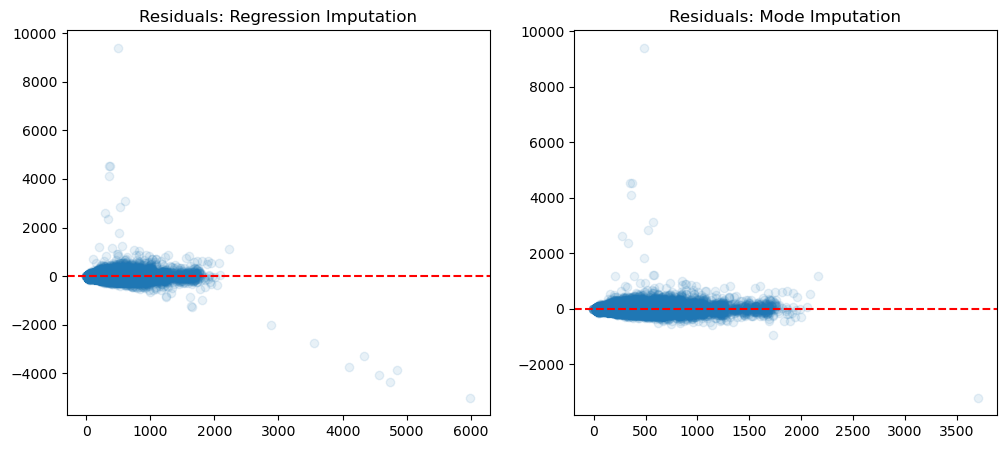

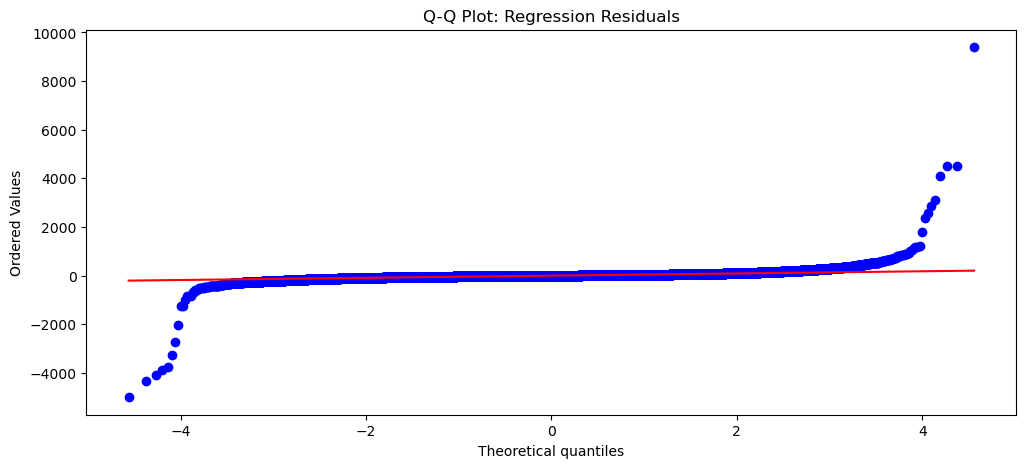

In [6]:
#Visual Validation (Residual & Q-Q Plots)
#Patterns in residuals reveal inadequacies in the model or violations of assumptions.
# 3. Plotting Residuals 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_reg, res_reg, alpha=0.1)
plt.title("Residuals: Regression Imputation")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(preds_mode, res_mode, alpha=0.1)
plt.title("Residuals: Mode Imputation")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# 4. Q-Q Plot for Normality Check [cite: 64]
plt.figure(figsize=(12, 5))
stats.probplot(res_reg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Regression Residuals")
plt.show()

In [7]:
# 3. Kolmogorov-Smirnov (K-S) Test
# Use this to compare the two imputed samples to see which one "departs" more from the expected distribution.
# Compare the distribution of a key imputed column (e.g., HSMainSystemEfficiency)
# to see which method distorted the original distribution more.
ks_stat, p_val = stats.ks_2samp(df_reg['HSMainSystemEfficiency'], df_mode['HSMainSystemEfficiency'])

print(f"\nKolmogorov-Smirnov Test: {ks_stat:.4f} (p-value: {p_val:.4f})")
if p_val < 0.05:
    print("The two imputation methods resulted in significantly different distributions.")


Kolmogorov-Smirnov Test: 0.0174 (p-value: 0.0000)
The two imputation methods resulted in significantly different distributions.


In [8]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def clean_and_predict(file_path, label):
    # Load and drop the high-null column per lecture advice [cite: 838]
    df = pd.read_parquet(file_path).drop(columns=['PredominantRoofType'])
    
    # Identify numeric columns for the model
    X_cols = df.select_dtypes(include=[np.number]).columns.drop('BerRating').tolist()
    X = df[X_cols]
    y = df['BerRating']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initial Baseline Prediction
    model = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # --- LECTURE STEP: Outlier Detection via Residuals [cite: 15, 68] ---
    residuals = y_test - preds
    z_scores = np.abs(stats.zscore(residuals))
    
    # Keep only those within 3 standard deviations [cite: 29]
    filtered_mask = z_scores < 3
    y_test_clean = y_test[filtered_mask]
    preds_clean = preds[filtered_mask]
    
    print(f"\n--- {label} (Post-Outlier Removal) ---")
    print(f"Original Row Count: {len(y_test)}")
    print(f"Cleaned Row Count: {len(y_test_clean)}")
    print(f"MSE: {mean_squared_error(y_test_clean, preds_clean):.4f}")
    print(f"R-squared: {r2_score(y_test_clean, preds_clean):.4f}")
    
    return y_test_clean, preds_clean

# Run Comparison
reg_results = clean_and_predict('BER_Cleaned_Imputed_Regression.parquet', "Regression Imputation")
mode_results = clean_and_predict('BER_Cleaned_Final_fill_missing_values.parquet', "Mode Imputation")


--- Regression Imputation (Post-Outlier Removal) ---
Original Row Count: 270317
Cleaned Row Count: 268124
MSE: 1286.9952
R-squared: 0.9373

--- Mode Imputation (Post-Outlier Removal) ---
Original Row Count: 270317
Cleaned Row Count: 267514
MSE: 1286.4727
R-squared: 0.9362


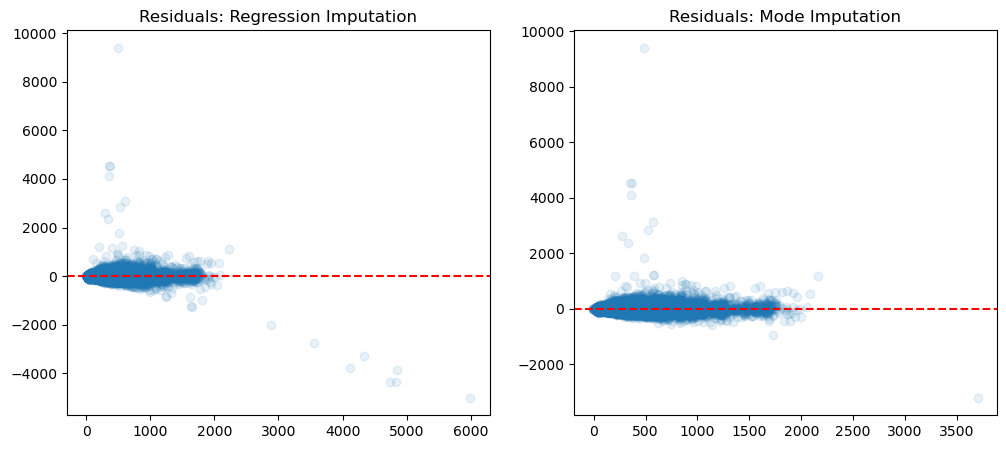

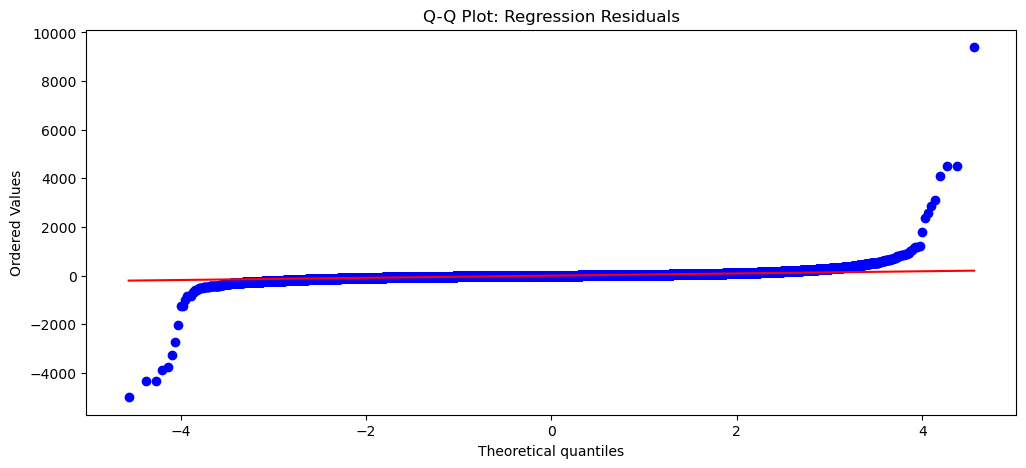

In [ ]:
#Visual Validation (Residual & Q-Q Plots)
#Patterns in residuals reveal inadequacies in the model or violations of assumptions.
# 3. Plotting Residuals 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_reg, res_reg, alpha=0.1)
plt.title("Residuals: Regression Imputation")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(preds_mode, res_mode, alpha=0.1)
plt.title("Residuals: Mode Imputation")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# 4. Q-Q Plot for Normality Check [cite: 64]
plt.figure(figsize=(12, 5))
stats.probplot(res_reg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Regression Residuals")
plt.show()

In [48]:
# 3. Kolmogorov-Smirnov (K-S) Test
# Use this to compare the two imputed samples to see which one "departs" more from the expected distribution.
# Compare the distribution of a key imputed column (e.g., HSMainSystemEfficiency)
# to see which method distorted the original distribution more.
ks_stat, p_val = stats.ks_2samp(df_reg['HSMainSystemEfficiency'], df_mode['HSMainSystemEfficiency'])

print(f"\nKolmogorov-Smirnov Test: {ks_stat:.4f} (p-value: {p_val:.4f})")
if p_val < 0.05:
    print("The two imputation methods resulted in significantly different distributions.")


Kolmogorov-Smirnov Test: 0.0174 (p-value: 0.0000)
The two imputation methods resulted in significantly different distributions.


In [23]:
def process_chunk(chunk, dwelling_encoder, trained_models, label_encoders, global_stats):
    chunk = chunk.copy()
    
    # ============================================================
    # STEP 1: 3-Sigma Numerical Smoothing (Remove Glitches)
    # Logic: Values outside Mean +/- 3s are "Out of Control" [cite: 27]
    # ============================================================
    for col, stats in global_stats.items():
        if col in chunk.columns:
            mean = stats['mean']
            std = stats['std']
            
            # Define error bounds per lecture [cite: 14, 24]
            upper_limit = mean + (3 * std)
            lower_limit = mean - (3 * std)
            
            # Replace outliers with the mean to smooth the data [cite: 702, 816]
            outlier_mask = (chunk[col] > upper_limit) | (chunk[col] < lower_limit)
            chunk.loc[outlier_mask, col] = mean

    # ============================================================
    # GROUP 1: Systems Block (NMAR) → Logical Zero-Fill
    # Logic: Missing values and defaults are indistinguishable [cite: 195, 208]
    # ============================================================
    zero_fill_num = [
        'HSSupplHeatFraction', 
        'SHRenewableResources', 
        'WHRenewableResources', 
        'HSSupplSystemEff', 
        'WHEffAdjFactor',
        'HSMainSystemEfficiency',
        'WHMainSystemEff',
    ]
    chunk[zero_fill_num] = chunk[zero_fill_num].fillna(0)
    chunk[['SupplSHFuel', 'SupplWHFuel']] = chunk[['SupplSHFuel', 'SupplWHFuel']].fillna(0)
    
    # ============================================================
    # GROUP 2: Building Envelope (MAR) → Regression Fill [cite: 264, 267]
    # Logic: Use attribute relationships to estimate missing values
    # ============================================================
    chunk['DwellingTypeDescr_enc'] = dwelling_encoder.transform(chunk['DwellingTypeDescr'].astype(str))
    X_chunk = chunk[['Year_of_Construction', 'DwellingTypeDescr_enc']].values
    
    for col, (task_type, model) in trained_models.items():
        null_mask = chunk[col].isnull()
        if null_mask.any():
            X_null = X_chunk[null_mask]
            predicted = model.predict(X_null)
            
            if task_type == 'classification':
                le = label_encoders[col]
                chunk.loc[null_mask, col] = le.inverse_transform(predicted.astype(int))
            else:
                chunk.loc[null_mask, col] = predicted.round(1)
                # Apply this logic within your process_chunk function
            # Priority: Logical Zero-Fill for the specific skipped block
            if 'HSEffAdjFactor' in chunk.columns:
                chunk['HSEffAdjFactor'] = chunk['HSEffAdjFactor'].fillna(0)
            

    # Final cleanup
    chunk.drop(columns=['DwellingTypeDescr_enc'], inplace=True)
    return chunk

In [24]:
# Pass 1: Calculate Global Statistics for 3-Sigma Bounds
numeric_cols = [
    'UValueWall', 'UValueRoof', 'UValueFloor', 'UValueWindow', 
    'WallArea', 'RoofArea', 'FloorArea', 'HSMainSystemEfficiency'
]

global_stats = {}
for col in numeric_cols:
    # Use a representative sample or the whole file (metadata only)
    # For simplicity, we calculate from a large sample here
    sample = pd.read_parquet(input_file, columns=[col])[col].dropna()
    global_stats[col] = {
        'mean': sample.mean(),
        'std': sample.std()
    }
print("✅ Global 3-Sigma bounds calculated.")

✅ Global 3-Sigma bounds calculated.


In [25]:
import pyarrow.parquet as pq
import pyarrow as pa

input_file = '46_Col_final_with_county.parquet'
output_file = 'BER_Cleaned_Imputed_Regression.parquet'
parquet_file = pq.ParquetFile(input_file)

writer = None 

for i in range(parquet_file.num_row_groups):
    print(f"Processing row group {i+1}/{parquet_file.num_row_groups}...")
    chunk = parquet_file.read_row_group(i).to_pandas()
    
    # FIX: Added global_stats to the function call
    cleaned_chunk = process_chunk(
        chunk, 
        dwelling_encoder, 
        trained_models, 
        label_encoders, 
        global_stats
    )
    
    table = pa.Table.from_pandas(cleaned_chunk)
    if writer is None:
        writer = pq.ParquetWriter(output_file, table.schema)
    writer.write_table(table)

if writer:
    writer.close()

print(f"\n✅ Done! Cleaned file saved to: {output_file}")

Processing row group 1/2...


/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/3473607152.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[97.9 97.5 97.8 ... 98.6 98.5 98.6]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/3473607152.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.2 2.7 2.3 ... 2.4 2.6 2.4]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/3473607152.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.3 2.3 2.2 ... 2.8

Processing row group 2/2...

✅ Done! Cleaned file saved to: BER_Cleaned_Imputed_Regression.parquet


/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/3473607152.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[98.5 98.5 98.5 ... 98.6 98.6 98.5]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/3473607152.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.3 2.3 2.2 ... 2.4 2.4 2.6]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  chunk.loc[null_mask, col] = predicted.round(1)
/var/folders/57/w47msrcj2218pj_05_xt1n0c0000gn/T/ipykernel_70040/3473607152.py:54: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[2.6 2.6 2.5 ... 2.8

In [26]:
import pandas as pd
import pyarrow.parquet as pq
# Path to your downloaded .txt file
input_file = 'BER_Cleaned_Imputed_Regression.parquet'
# Path where you want to save the new .csv

chunk_size = 100000
null_counts = None
total_rows = 0
parquet_file = pq.ParquetFile(input_file)

# Iterate through "Row Groups" (the Parquet version of chunks)
for i in range(parquet_file.num_row_groups):
    chunk = parquet_file.read_row_group(i).to_pandas()
    if null_counts is None:
        null_counts = chunk.isnull().sum()
    else:
        null_counts += chunk.isnull().sum()
    total_rows += len(chunk)

# Get the list
null_percentages = null_counts / total_rows
sorted_null_counts = null_counts.sort_values(ascending=False)
print(sorted_null_counts[sorted_null_counts>0])

PredominantRoofType    141260
dtype: int64


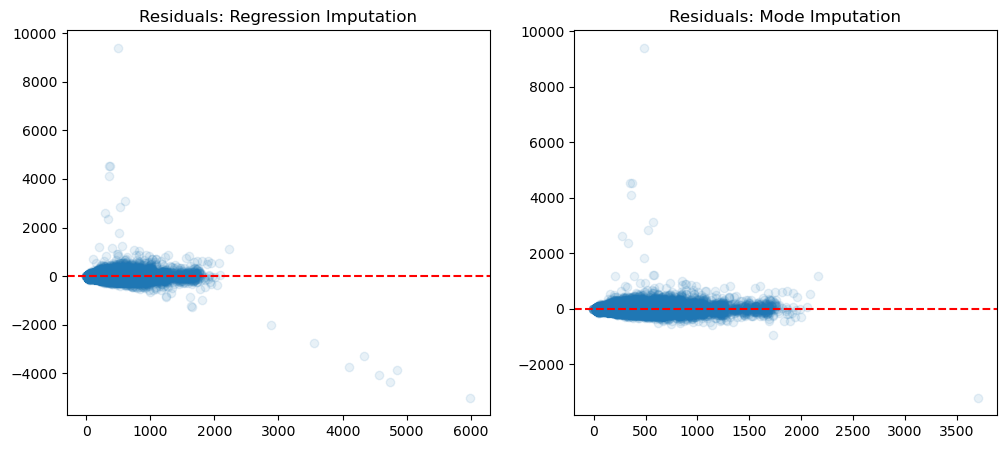

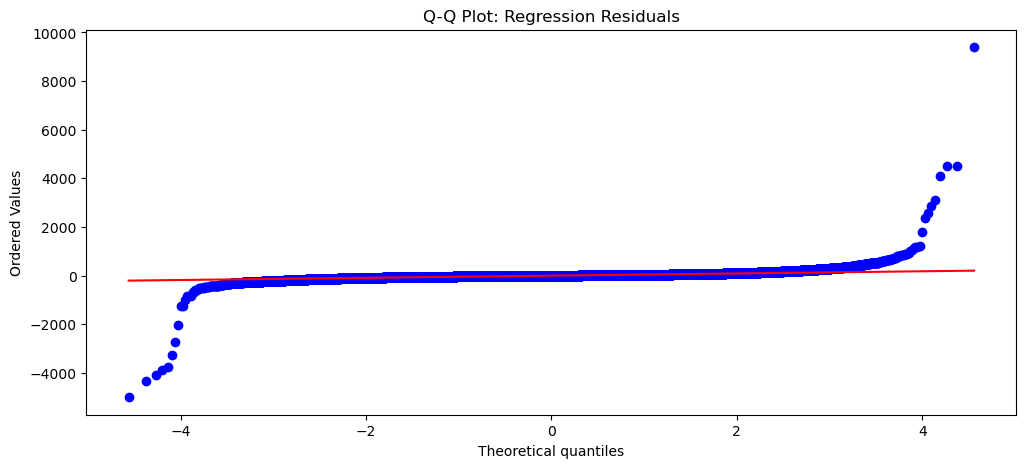

In [27]:
#Visual Validation (Residual & Q-Q Plots)
#Patterns in residuals reveal inadequacies in the model or violations of assumptions.
# 3. Plotting Residuals 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_reg, res_reg, alpha=0.1)
plt.title("Residuals: Regression Imputation")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(preds_mode, res_mode, alpha=0.1)
plt.title("Residuals: Mode Imputation")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# 4. Q-Q Plot for Normality Check [cite: 64]
plt.figure(figsize=(12, 5))
stats.probplot(res_reg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Regression Residuals")
plt.show()

In [28]:
# 3. Kolmogorov-Smirnov (K-S) Test
# Use this to compare the two imputed samples to see which one "departs" more from the expected distribution.
# Compare the distribution of a key imputed column (e.g., HSMainSystemEfficiency)
# to see which method distorted the original distribution more.
ks_stat, p_val = stats.ks_2samp(df_reg['HSMainSystemEfficiency'], df_mode['HSMainSystemEfficiency'])

print(f"\nKolmogorov-Smirnov Test: {ks_stat:.4f} (p-value: {p_val:.4f})")
if p_val < 0.05:
    print("The two imputation methods resulted in significantly different distributions.")


Kolmogorov-Smirnov Test: 0.0174 (p-value: 0.0000)
The two imputation methods resulted in significantly different distributions.


In [29]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

def clean_and_predict(file_path, label):
    # Load and drop the high-null column per lecture advice [cite: 838]
    df = pd.read_parquet(file_path).drop(columns=['PredominantRoofType'])
    
    # Identify numeric columns for the model
    X_cols = df.select_dtypes(include=[np.number]).columns.drop('BerRating').tolist()
    X = df[X_cols]
    y = df['BerRating']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Initial Baseline Prediction
    model = RandomForestRegressor(n_estimators=100, max_depth=12, n_jobs=-1, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    # --- LECTURE STEP: Outlier Detection via Residuals [cite: 15, 68] ---
    residuals = y_test - preds
    z_scores = np.abs(stats.zscore(residuals))
    
    # Keep only those within 3 standard deviations [cite: 29]
    filtered_mask = z_scores < 3
    y_test_clean = y_test[filtered_mask]
    preds_clean = preds[filtered_mask]
    
    print(f"\n--- {label} (Post-Outlier Removal) ---")
    print(f"Original Row Count: {len(y_test)}")
    print(f"Cleaned Row Count: {len(y_test_clean)}")
    print(f"MSE: {mean_squared_error(y_test_clean, preds_clean):.4f}")
    print(f"R-squared: {r2_score(y_test_clean, preds_clean):.4f}")
    
    return y_test_clean, preds_clean

# Run Comparison
reg_results = clean_and_predict('BER_Cleaned_Imputed_Regression.parquet', "Regression Imputation")
mode_results = clean_and_predict('BER_Cleaned_Final_fill_missing_values.parquet', "Mode Imputation")


--- Regression Imputation (Post-Outlier Removal) ---
Original Row Count: 270317
Cleaned Row Count: 267812
MSE: 1373.3919
R-squared: 0.9320

--- Mode Imputation (Post-Outlier Removal) ---
Original Row Count: 270317
Cleaned Row Count: 267514
MSE: 1286.4727
R-squared: 0.9362


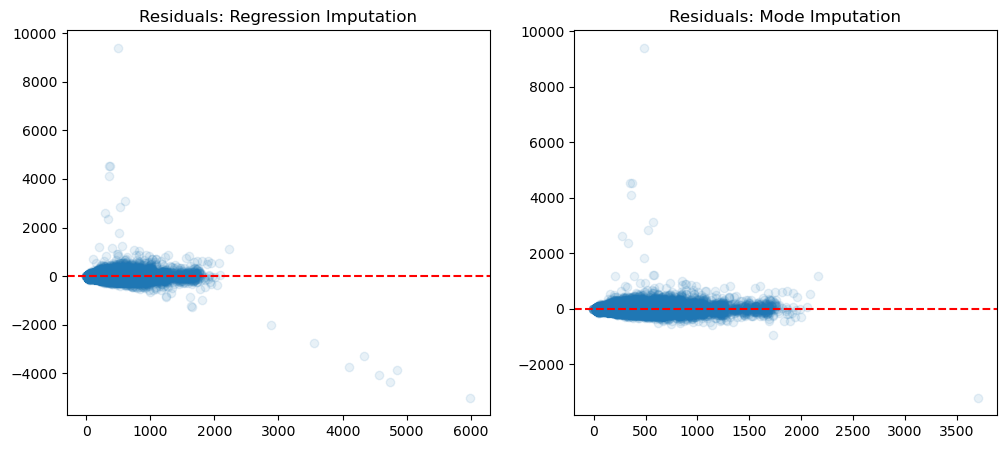

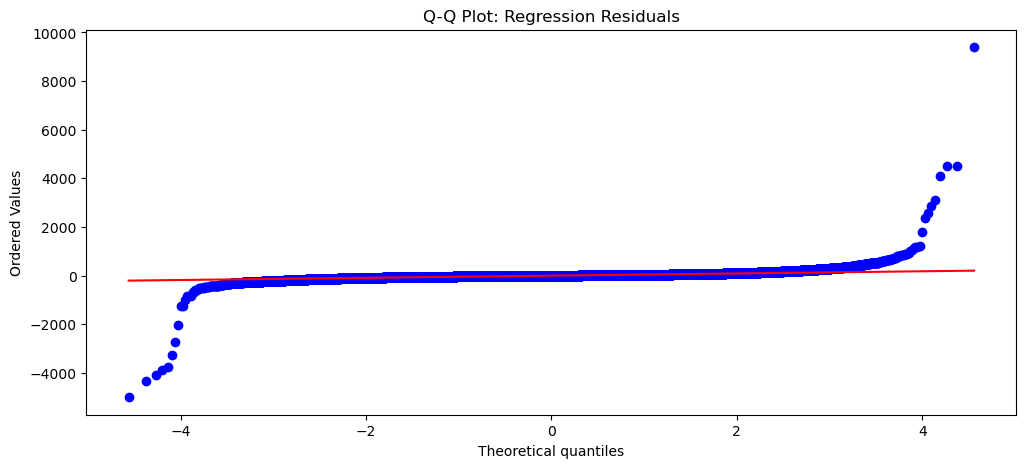

In [30]:
#Visual Validation (Residual & Q-Q Plots)
#Patterns in residuals reveal inadequacies in the model or violations of assumptions.
# 3. Plotting Residuals 
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(preds_reg, res_reg, alpha=0.1)
plt.title("Residuals: Regression Imputation")
plt.axhline(0, color='red', linestyle='--')

plt.subplot(1, 2, 2)
plt.scatter(preds_mode, res_mode, alpha=0.1)
plt.title("Residuals: Mode Imputation")
plt.axhline(0, color='red', linestyle='--')
plt.show()

# 4. Q-Q Plot for Normality Check [cite: 64]
plt.figure(figsize=(12, 5))
stats.probplot(res_reg, dist="norm", plot=plt)
plt.title("Q-Q Plot: Regression Residuals")
plt.show()

In [31]:
# 3. Kolmogorov-Smirnov (K-S) Test
# Use this to compare the two imputed samples to see which one "departs" more from the expected distribution.
# Compare the distribution of a key imputed column (e.g., HSMainSystemEfficiency)
# to see which method distorted the original distribution more.
ks_stat, p_val = stats.ks_2samp(df_reg['HSMainSystemEfficiency'], df_mode['HSMainSystemEfficiency'])

print(f"\nKolmogorov-Smirnov Test: {ks_stat:.4f} (p-value: {p_val:.4f})")
if p_val < 0.05:
    print("The two imputation methods resulted in significantly different distributions.")


Kolmogorov-Smirnov Test: 0.0174 (p-value: 0.0000)
The two imputation methods resulted in significantly different distributions.


In [32]:
import pandas as pd
from scipy.stats import ks_2samp

# 1. Load your two versions of the data
df_reg = pd.read_parquet('BER_Cleaned_Imputed_Regression.parquet')
df_mode = pd.read_parquet('BER_Cleaned_Final_fill_missing_values.parquet')

# 2. Select a key column that was imputed (e.g., HSMainSystemEfficiency)
# It is important to compare the same attribute across both methods
column_to_test = 'HSMainSystemEfficiency'

data_reg = df_reg[column_to_test].dropna()
data_mode = df_mode[column_to_test].dropna()

# 3. Perform the Two-Sample Kolmogorov-Smirnov Test
statistic, p_value = ks_2samp(data_reg, data_mode)

print(f"K-S Statistic: {statistic:.4f}")
print(f"P-Value: {p_value:.4e}")

# 4. Interpret the results based on lecture criteria
alpha = 0.05
if p_value < alpha:
    print("\nVerdict: Significantly Different Distributions.")
    print("The imputation methods have created statistically distinct data profiles.")
else:
    print("\nVerdict: Distributions are Similar.")
    print("The imputation methods preserved the same underlying distribution.")

K-S Statistic: 0.1053
P-Value: 0.0000e+00

Verdict: Significantly Different Distributions.
The imputation methods have created statistically distinct data profiles.


STEP 1: Loading Data
Shape: (1351582, 46)

Missing values:
PredominantRoofType    141260
dtype: int64

PredominantRoofType missing: 141260 (10.5%)

STEP 2: Evaluating PredominantRoofType Contribution

Rows with PredominantRoofType: 1210322
Correlation of PredominantRoofType with BerRating: 0.0223
ANOVA F-statistic: 335.7150, p-value: 0.000000
>> PredominantRoofType has SIGNIFICANT effect on BerRating

BerRating by PredominantRoofType:
                                      mean         std    count
PredominantRoofType                                            
Other                           126.128593   52.312332      641
Flat Roof                       190.575287  165.568054    73871
Room in Roof-Insul.on side      203.508621  115.088440    48177
Pitch Roof-Insul.on Ceiling     211.075363  162.886581  1015678
Pitch Roof-Insul.on Rafter      225.067215  215.376343    69627
                                248.371323  155.121613     2326
Select Roof Type                417.705017    0.0

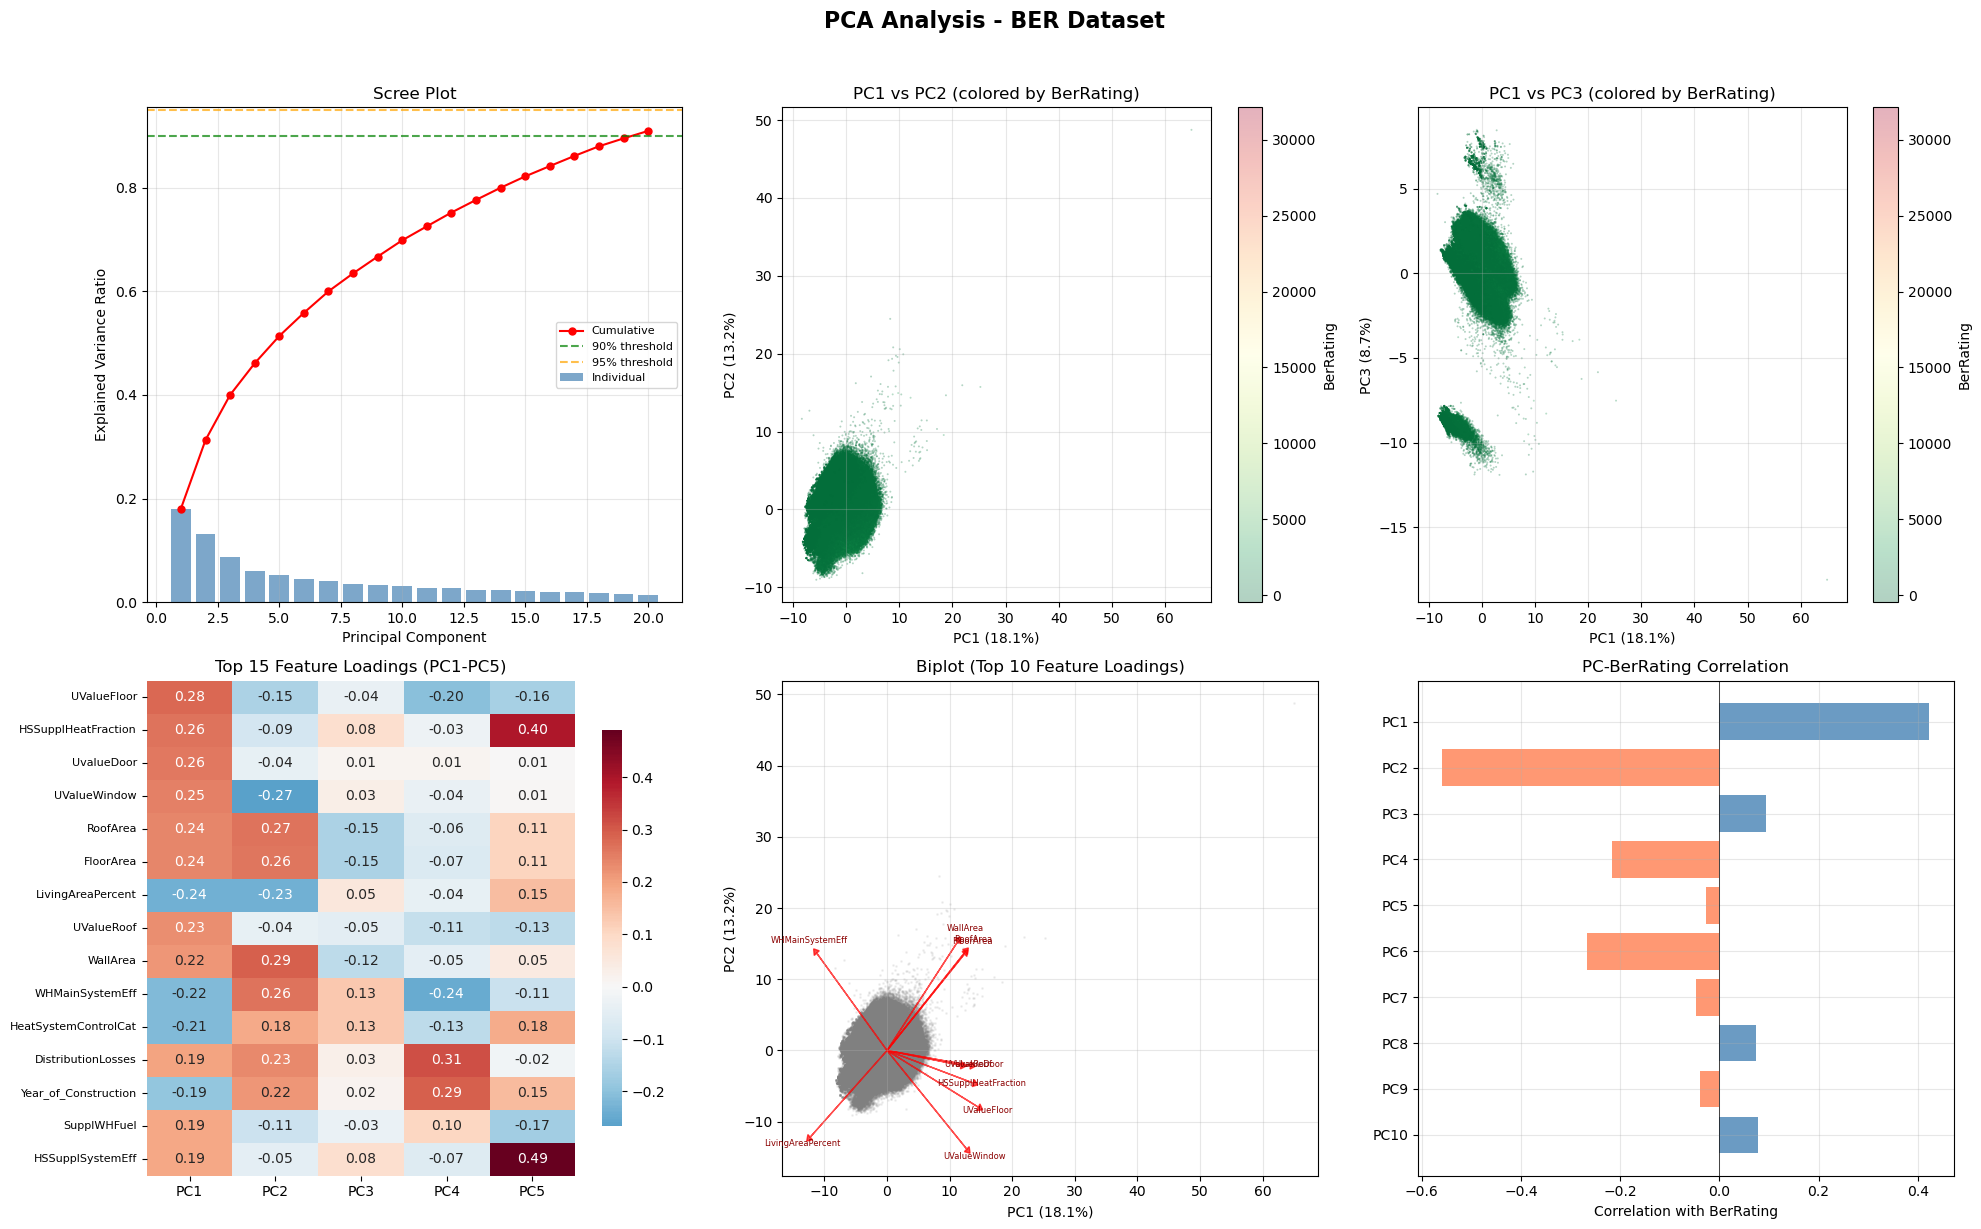

Saved: pca_analysis.png

STEP 6: FDA / LDA Analysis (DwellingType as class)
Number of classes: 11
LDA components: 10
Classes: ['Apartment', 'Basement Dwelling', 'Detached house', 'End of terrace house', 'Ground-floor apartment', 'House', 'Maisonette', 'Mid-floor apartment', 'Mid-terrace house', 'Semi-detached house', 'Top-floor apartment']

LDA explained variance ratios:
  LD1: 0.5884
  LD2: 0.2059
  LD3: 0.1598
  LD4: 0.0226
  LD5: 0.0123


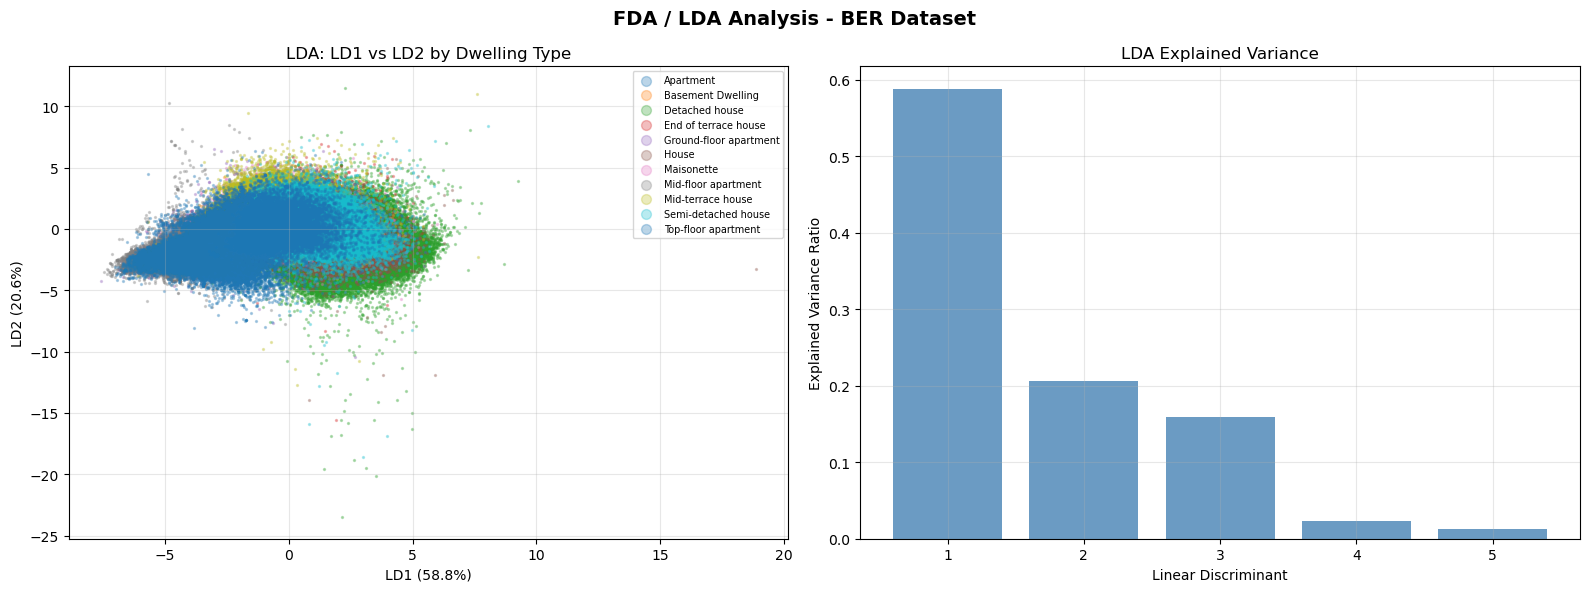

Saved: fda_lda_analysis.png

STEP 7: PCA vs FDA Comparison

Comparing classification accuracy (Logistic Regression, 5-fold CV):
Using DwellingTypeDescr as target class

PCA (20 components): 0.6765 +/- 0.0074
LDA (5 components): 0.7541 +/- 0.0058
Original (31 features): 0.7653 +/- 0.0066

ANALYSIS COMPLETE

Files saved:
  - pca_analysis.png
  - fda_lda_analysis.png (if FDA ran)


In [36]:
"""
=============================================================================
BER Dataset - PCA & FDA Analysis Pipeline
=============================================================================
Run this script on your local machine with your cleaned dataset.
Update the FILE_PATH variable below to point to your CSV.

Requirements: pip install pandas numpy scikit-learn matplotlib seaborn
=============================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIG - UPDATE THIS PATH
# ============================================================
FILE_PATH = "BER_Cleaned_Imputed_Regression.parquet"  # <-- Update this

# Columns from your dataset
CATEGORICAL_COLS = [
    'DwellingTypeDescr', 'VentilationMethod', 'StructureType',
    'SuspendedWoodenFloor', 'PredominantRoofType', 'ThermalMassCategory',
    'CHBoilerThermostatControlled', 'OBBoilerThermostatControlled',
    'OBPumpInsideDwelling', 'WarmAirHeatingSystem', 'UndergroundHeating',
    'CylinderStat', 'CombinedCylinder'
]

TARGET_COL = 'BerRating'

# ============================================================
# STEP 1: Load & Inspect
# ============================================================
print("=" * 70)
print("STEP 1: Loading Data")
print("=" * 70)

df = pd.read_parquet(FILE_PATH)
print(f"Shape: {df.shape}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nPredominantRoofType missing: {df['PredominantRoofType'].isnull().sum()} "
      f"({df['PredominantRoofType'].isnull().mean()*100:.1f}%)")

# ============================================================
# STEP 2: Evaluate PredominantRoofType Contribution
# ============================================================
print("\n" + "=" * 70)
print("STEP 2: Evaluating PredominantRoofType Contribution")
print("=" * 70)

# 2a. Check correlation with target (BerRating) for rows that have values
df_roof = df.dropna(subset=['PredominantRoofType']).copy()
print(f"\nRows with PredominantRoofType: {len(df_roof)}")

# Encode roof type for correlation analysis
le_roof = LabelEncoder()
df_roof['RoofType_Encoded'] = le_roof.fit_transform(df_roof['PredominantRoofType'].astype(str))

# Correlation with BerRating
corr_with_target = df_roof['RoofType_Encoded'].corr(df_roof[TARGET_COL])
print(f"Correlation of PredominantRoofType with BerRating: {corr_with_target:.4f}")

# ANOVA: Does BerRating differ across roof types?
roof_groups = [group[TARGET_COL].values for name, group in df_roof.groupby('PredominantRoofType')]
if len(roof_groups) > 1:
    f_stat, p_val = stats.f_oneway(*roof_groups)
    print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.6f}")
    if p_val < 0.05:
        print(">> PredominantRoofType has SIGNIFICANT effect on BerRating")
    else:
        print(">> PredominantRoofType has NO significant effect on BerRating")

# 2b. BerRating distribution by roof type
print(f"\nBerRating by PredominantRoofType:")
print(df_roof.groupby('PredominantRoofType')[TARGET_COL].agg(['mean', 'std', 'count']).sort_values('mean'))

# 2c. Variance contribution check via mini-PCA
print("\n--- Mini-PCA: With vs Without PredominantRoofType ---")
numeric_cols_roof = df_roof.select_dtypes(include=[np.number]).columns.tolist()
if TARGET_COL in numeric_cols_roof:
    numeric_cols_roof.remove(TARGET_COL)

# Without roof type
X_no_roof = df_roof[numeric_cols_roof].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_no_roof)
pca_temp = PCA(n_components=min(5, X_scaled.shape[1]))
pca_temp.fit(X_scaled)
var_without = pca_temp.explained_variance_ratio_.sum()
print(f"Top 5 PCs variance (WITHOUT RoofType): {var_without:.4f}")

# With roof type (one-hot encoded)
roof_dummies = pd.get_dummies(df_roof['PredominantRoofType'], prefix='Roof', drop_first=True)
X_with_roof = pd.concat([df_roof[numeric_cols_roof], roof_dummies], axis=1).dropna()
X_scaled2 = scaler.fit_transform(X_with_roof)
pca_temp2 = PCA(n_components=min(5, X_scaled2.shape[1]))
pca_temp2.fit(X_scaled2)
var_with = pca_temp2.explained_variance_ratio_.sum()
print(f"Top 5 PCs variance (WITH RoofType):    {var_with:.4f}")
print(f"Difference: {(var_with - var_without)*100:.2f}%")

# DECISION
print("\n" + "-" * 50)
if abs(corr_with_target) < 0.1 and (var_with - var_without) < 0.01:
    KEEP_ROOF = False
    print("RECOMMENDATION: DROP PredominantRoofType")
    print("  - Low correlation with target")
    print("  - Minimal variance contribution in PCA")
    print("  - 52% missing would require heavy imputation")
else:
    KEEP_ROOF = True
    print("RECOMMENDATION: KEEP PredominantRoofType")
    print(f"  - Correlation with target: {corr_with_target:.4f}")
    print(f"  - PCA variance gain: {(var_with - var_without)*100:.2f}%")
    print("  - Consider mode imputation for missing values")
print("-" * 50)

# ============================================================
# STEP 3: Prepare Data for PCA
# ============================================================
print("\n" + "=" * 70)
print("STEP 3: Preparing Data for PCA")
print("=" * 70)

df_pca = df.copy()

# Handle PredominantRoofType based on recommendation
if not KEEP_ROOF:
    df_pca = df_pca.drop(columns=['PredominantRoofType'])
    print("Dropped PredominantRoofType")
else:
    df_pca['PredominantRoofType'].fillna(df_pca['PredominantRoofType'].mode()[0], inplace=True)
    print("Imputed PredominantRoofType with mode")

# Encode remaining categoricals
cat_cols_present = [c for c in CATEGORICAL_COLS if c in df_pca.columns]
for col in cat_cols_present:
    if df_pca[col].dtype == 'object':
        df_pca[col] = LabelEncoder().fit_transform(df_pca[col].astype(str))

# Select numeric features (exclude target)
feature_cols = [c for c in df_pca.select_dtypes(include=[np.number]).columns if c != TARGET_COL]
X = df_pca[feature_cols].dropna()
y = df_pca.loc[X.index, TARGET_COL]

print(f"Features: {len(feature_cols)}")
print(f"Samples: {len(X)}")

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 4: PCA Analysis
# ============================================================
print("\n" + "=" * 70)
print("STEP 4: PCA Analysis")
print("=" * 70)

# Full PCA
pca_full = PCA()
X_pca = pca_full.fit_transform(X_scaled)

# Explained variance
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumulative_var >= 0.90) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"\nTotal features: {len(feature_cols)}")
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {n_95}")
print(f"\nTop 10 components explained variance:")
for i in range(min(10, len(pca_full.explained_variance_ratio_))):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} "
          f"(cumulative: {cumulative_var[i]:.4f})")

# ============================================================
# STEP 5: Visualizations
# ============================================================
print("\n" + "=" * 70)
print("STEP 5: Generating Visualizations")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('PCA Analysis - BER Dataset', fontsize=16, fontweight='bold', y=1.02)

# --- Plot 1: Scree Plot ---
ax = axes[0, 0]
n_show = min(20, len(pca_full.explained_variance_ratio_))
ax.bar(range(1, n_show+1), pca_full.explained_variance_ratio_[:n_show],
       alpha=0.7, color='steelblue', label='Individual')
ax.plot(range(1, n_show+1), cumulative_var[:n_show],
        'ro-', markersize=5, label='Cumulative')
ax.axhline(y=0.90, color='green', linestyle='--', alpha=0.7, label='90% threshold')
ax.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, label='95% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('Scree Plot')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 2: PC1 vs PC2 scatter ---
ax = axes[0, 1]
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='RdYlGn_r',
                     alpha=0.3, s=2, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='BerRating')
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
ax.set_title('PC1 vs PC2 (colored by BerRating)')
ax.grid(True, alpha=0.3)

# --- Plot 3: PC1 vs PC3 scatter ---
ax = axes[0, 2]
if X_pca.shape[1] >= 3:
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 2], c=y, cmap='RdYlGn_r',
                         alpha=0.3, s=2, edgecolors='none')
    plt.colorbar(scatter, ax=ax, label='BerRating')
    ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC3 ({pca_full.explained_variance_ratio_[2]:.1%})')
    ax.set_title('PC1 vs PC3 (colored by BerRating)')
    ax.grid(True, alpha=0.3)

# --- Plot 4: Feature Loadings Heatmap (Top PCs) ---
ax = axes[1, 0]
n_pcs_show = min(5, len(pca_full.components_))
loadings = pd.DataFrame(
    pca_full.components_[:n_pcs_show].T,
    columns=[f'PC{i+1}' for i in range(n_pcs_show)],
    index=feature_cols
)
# Show top 15 features by absolute loading on PC1
top_features = loadings['PC1'].abs().nlargest(15).index
sns.heatmap(loadings.loc[top_features], annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Top 15 Feature Loadings (PC1-PC5)')
ax.set_ylabel('')
plt.setp(ax.get_yticklabels(), fontsize=8)

# --- Plot 5: Biplot (PC1 vs PC2 with loading arrows) ---
ax = axes[1, 1]
# Plot samples
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.1, s=1, color='gray')
# Plot loading arrows for top features
top_10 = loadings['PC1'].abs().nlargest(10).index
scale_factor = np.max(np.abs(X_pca[:, :2])) * 0.8

for feat in top_10:
    idx = feature_cols.index(feat)
    ax.arrow(0, 0,
             pca_full.components_[0, idx] * scale_factor,
             pca_full.components_[1, idx] * scale_factor,
             head_width=scale_factor*0.02, head_length=scale_factor*0.015,
             fc='red', ec='red', alpha=0.7)
    ax.text(pca_full.components_[0, idx] * scale_factor * 1.1,
            pca_full.components_[1, idx] * scale_factor * 1.1,
            feat, fontsize=6, color='darkred', ha='center')
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%})')
ax.set_title('Biplot (Top 10 Feature Loadings)')
ax.grid(True, alpha=0.3)

# --- Plot 6: Correlation of PCs with BerRating ---
ax = axes[1, 2]
n_corr = min(10, X_pca.shape[1])
pc_target_corr = [np.corrcoef(X_pca[:, i], y)[0, 1] for i in range(n_corr)]
colors = ['steelblue' if c >= 0 else 'coral' for c in pc_target_corr]
ax.barh(range(n_corr), pc_target_corr, color=colors, alpha=0.8)
ax.set_yticks(range(n_corr))
ax.set_yticklabels([f'PC{i+1}' for i in range(n_corr)])
ax.set_xlabel('Correlation with BerRating')
ax.set_title('PC-BerRating Correlation')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: pca_analysis.png")

# ============================================================
# STEP 6: FDA / LDA (Optional - using DwellingType as class)
# ============================================================
print("\n" + "=" * 70)
print("STEP 6: FDA / LDA Analysis (DwellingType as class)")
print("=" * 70)

if 'DwellingTypeDescr' in df.columns:
    # Encode dwelling type
    le_dwelling = LabelEncoder()
    y_class = le_dwelling.fit_transform(df_pca.loc[X.index, 'DwellingTypeDescr'].astype(str))
    class_names = le_dwelling.classes_

    n_classes = len(np.unique(y_class))
    n_components_lda = min(n_classes - 1, X_scaled.shape[1])
    print(f"Number of classes: {n_classes}")
    print(f"LDA components: {n_components_lda}")
    print(f"Classes: {list(class_names)}")

    lda = LDA(n_components=min(n_components_lda, 5))
    X_lda = lda.fit_transform(X_scaled, y_class)

    print(f"\nLDA explained variance ratios:")
    for i, ratio in enumerate(lda.explained_variance_ratio_):
        print(f"  LD{i+1}: {ratio:.4f}")

    # FDA Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('FDA / LDA Analysis - BER Dataset', fontsize=14, fontweight='bold')

    # LD1 vs LD2
    ax = axes[0]
    for i, name in enumerate(class_names):
        mask = y_class == i
        ax.scatter(X_lda[mask, 0], X_lda[mask, 1] if X_lda.shape[1] > 1 else np.zeros(mask.sum()),
                   label=name, alpha=0.3, s=2)
    ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
    if X_lda.shape[1] > 1:
        ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
    ax.set_title('LDA: LD1 vs LD2 by Dwelling Type')
    ax.legend(fontsize=7, markerscale=5)
    ax.grid(True, alpha=0.3)

    # LDA explained variance
    ax = axes[1]
    ax.bar(range(1, len(lda.explained_variance_ratio_)+1),
           lda.explained_variance_ratio_, color='steelblue', alpha=0.8)
    ax.set_xlabel('Linear Discriminant')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title('LDA Explained Variance')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('fda_lda_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fda_lda_analysis.png")

    # ============================================================
    # STEP 7: PCA vs LDA Comparison
    # ============================================================
    print("\n" + "=" * 70)
    print("STEP 7: PCA vs FDA Comparison")
    print("=" * 70)

    from sklearn.model_selection import cross_val_score
    from sklearn.linear_model import LogisticRegression

    print("\nComparing classification accuracy (Logistic Regression, 5-fold CV):")
    print("Using DwellingTypeDescr as target class\n")

    # PCA with optimal components
    pca_opt = PCA(n_components=n_90)
    X_pca_opt = pca_opt.fit_transform(X_scaled)

    lr = LogisticRegression(max_iter=1000, random_state=42)

    # PCA
    scores_pca = cross_val_score(lr, X_pca_opt, y_class, cv=5, scoring='accuracy')
    print(f"PCA ({n_90} components): {scores_pca.mean():.4f} +/- {scores_pca.std():.4f}")

    # LDA
    scores_lda = cross_val_score(lr, X_lda, y_class, cv=5, scoring='accuracy')
    print(f"LDA ({X_lda.shape[1]} components): {scores_lda.mean():.4f} +/- {scores_lda.std():.4f}")

    # Original features
    scores_orig = cross_val_score(lr, X_scaled, y_class, cv=5, scoring='accuracy')
    print(f"Original ({X_scaled.shape[1]} features): {scores_orig.mean():.4f} +/- {scores_orig.std():.4f}")

    print("\n" + "=" * 70)
    print("ANALYSIS COMPLETE")
    print("=" * 70)
else:
    print("DwellingTypeDescr not found - skipping FDA/LDA")

print("\nFiles saved:")
print("  - pca_analysis.png")
print("  - fda_lda_analysis.png (if FDA ran)")

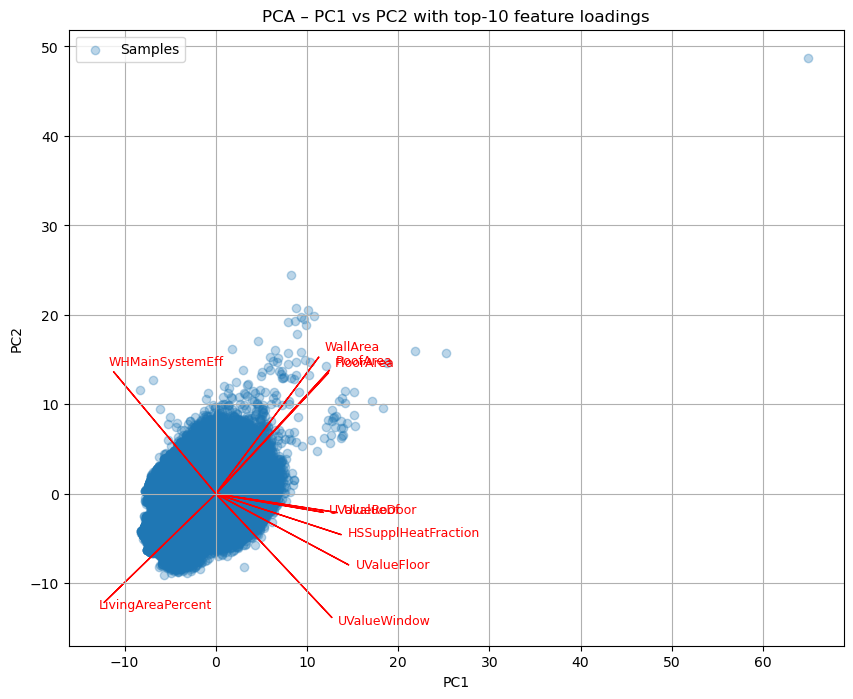

In [35]:
# -------------------------------------------------
# Visualise the first two principal components (PC1 & PC2)
# -------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Assume X_pca is the result of PCA applied to `X` (your feature matrix)
# X_pca shape: (n_samples, n_components)

# Plot the scores (the transformed data) for the first two PCs
plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, label='Samples')

# -------------------------------------------------
# Plot loading arrows for the top‑10 contributing features
# -------------------------------------------------
top_10 = loadings['PC1'].abs().nlargest(10).index

# **Corrected line** – compute a single scaling factor for the arrows
scale_factor = np.max(np.abs(X_pca[:, :2])) * 0.8   # 80 % of the max absolute PC value

for feat in top_10:
    idx = feature_cols.index(feat)          # column index in the original feature list
    # Arrow goes from (0,0) to the loading vector (scaled for visibility)
    plt.arrow(0, 0,
              loadings.loc[feat, 'PC1'] * scale_factor,
              loadings.loc[feat, 'PC2'] * scale_factor,
              color='r', width=0.005, head_width=0.02, length_includes_head=True)
    plt.text(loadings.loc[feat, 'PC1'] * scale_factor * 1.05,
             loadings.loc[feat, 'PC2'] * scale_factor * 1.05,
             feat, color='r', fontsize=9)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA – PC1 vs PC2 with top‑10 feature loadings')
plt.legend()
plt.grid(True)
plt.show()
